In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 데이터 생성

In [4]:
# 결과 재현성을 위한 시드 고정
np.random.seed(42)
random.seed(42)

n_users = 10000

In [5]:
# 1. 1만 명 유저 풀 생성 (A/B 그룹 및 지역 할당)
users = pd.DataFrame({
    'user_id': range(1, n_users + 1),
    'ui_group': np.random.choice(['A(기존 UI)', 'B(개선 UI)'], n_users, p=[0.5, 0.5]),
    'user_region': np.random.choice(['도심권', '외곽 주거지(초월읍 등)'], n_users, p=[0.7, 0.3])
})

logs = []

In [6]:
for _, user in users.iterrows():
    uid = user['user_id']
    group = user['ui_group']
    region = user['user_region']
    
    # 1단계: 진입 (Entry) - 10,000명 전원
    logs.append({'user_id': uid, 'step': '1_app_opened', 'event_name': 'app_opened', 'ui_group': group, 'user_region': region})
    
    # 2단계: 탐색 (Exploration) 도달 여부 
    # [목표 도달: 약 4,000명] A그룹은 진입 마찰로 20%만 통과, B그룹은 선탐색으로 60% 통과
    prob_home = 0.2 if group == 'A(기존 UI)' else 0.6 
    if random.random() <= prob_home:
        logs.append({'user_id': uid, 'step': '2_home_viewed', 'event_name': 'home_viewed', 'ui_group': group, 'user_region': region})
        
        # 3단계: 장바구니 (Cart) 도달 여부 
        # [목표 도달: 약 1,200명 (이탈률 70%)]
        prob_cart = 0.16 # 기본 장바구니 전환 확률
        if group == 'B(개선 UI)': prob_cart += 0.22             # 퀵필터 도입의 긍정적 효과
        if region == '외곽 주거지(초월읍 등)': prob_cart -= 0.08  # 높은 배달비로 인한 탐색 포기 패널티
            
        if random.random() <= prob_cart:
            logs.append({'user_id': uid, 'step': '3_cart_interacted', 'event_name': 'cart_interacted', 'ui_group': group, 'user_region': region})
            
            # 4단계: 구매 완료 (Purchase)
            # [목표 도달: 약 500명 (이탈률 58.3%)]
            prob_purchase = 0.45 # 기본 구매 전환 확률
            if region == '외곽 주거지(초월읍 등)': prob_purchase -= 0.15 # 구조적 한계(무료배달 부재)로 외곽 지역 결제 직전 포기 심화
            
            if random.random() <= prob_purchase:
                logs.append({'user_id': uid, 'step': '4_purchase_completed', 'event_name': 'purchase_completed', 'ui_group': group, 'user_region': region})



In [7]:
# 데이터프레임 변환 및 CSV 저장
log_df = pd.DataFrame(logs)
log_df.to_csv('delivery_app_logs.csv', index=False)
print("✅ 데이터 생성 완료! 단계별 도달 유저 수 확인:")
print(log_df['event_name'].value_counts())

✅ 데이터 생성 완료! 단계별 도달 유저 수 확인:
event_name
app_opened            10000
home_viewed            3942
cart_interacted        1186
purchase_completed      491
Name: count, dtype: int64


In [12]:
import os; print(os.getcwd())

/Users/yjh/코드_지리십조(에어비앤비 진입 추천 입지 & 전략 분석)


In [9]:
# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 퍼널 집계 및 세그먼트 분석 (EDA)

#### 전체 퍼널 단계별 도달 유저 수와 이탈률을 계산하고, A/B 테스트 그룹 및 지역별 세그먼트로 쪼개서 데이터를 확인

In [14]:
# 1. 로그 데이터 로드
df = pd.read_csv('delivery_app_logs.csv')
# 2. 전체 퍼널 단계별 유저 수 및 전환/이탈률 집계
step_order = ['1_app_opened', '2_home_viewed', '3_cart_interacted', '4_purchase_completed']
step_labels = ['1. 진입 (App Opened)', '2. 탐색 (Home Viewed)', '3. 장바구니 (Cart)', '4. 구매 완료 (Purchase)']

funnel_data = []
prev_users = None

for s, label in zip(step_order, step_labels):
    current_users = df[df['step'] == s]['user_id'].nunique()
    if prev_users is None:
        conv_rate = 100.0
        drop_rate = 0.0
    else:
        conv_rate = (current_users / prev_users) * 100
        drop_rate = 100.0 - conv_rate
    
    funnel_data.append({
        'Step': label,
        'Users': current_users,
        'Step_Conversion_Rate': f"{conv_rate:.1f}%" if prev_users else "100.0%",
        'Drop_Off_Rate': f"{drop_rate:.1f}%" if prev_users else "-"
    })
    prev_users = current_users

funnel_df = pd.DataFrame(funnel_data)
print("=== [STEP 1] 전체 퍼널 집계 결과 ===")
print(funnel_df.to_string(index=False))

# 3. 세그먼트 분석 (UI 그룹별 / 지역별)
print("\n=== [STEP 1-1] UI 그룹별 단계별 도달 유저 수 ===")
ui_group_funnel = df.groupby(['ui_group', 'step'])['user_id'].nunique().unstack(fill_value=0)[step_order]
print(ui_group_funnel)

print("\n=== [STEP 1-2] 지역별 단계별 도달 유저 수 ===")
region_funnel = df.groupby(['user_region', 'step'])['user_id'].nunique().unstack(fill_value=0)[step_order]
print(region_funnel)

=== [STEP 1] 전체 퍼널 집계 결과 ===
               Step  Users Step_Conversion_Rate Drop_Off_Rate
 1. 진입 (App Opened)  10000               100.0%             -
2. 탐색 (Home Viewed)   3942                39.4%         60.6%
     3. 장바구니 (Cart)   1186                30.1%         69.9%
4. 구매 완료 (Purchase)    491                41.4%         58.6%

=== [STEP 1-1] UI 그룹별 단계별 도달 유저 수 ===
step      1_app_opened  2_home_viewed  3_cart_interacted  4_purchase_completed
ui_group                                                                      
A(기존 UI)          5076           1017                146                    62
B(개선 UI)          4924           2925               1040                   429

=== [STEP 1-2] 지역별 단계별 도달 유저 수 ===
step           1_app_opened  2_home_viewed  3_cart_interacted  \
user_region                                                     
도심권                    6928           2695                876   
외곽 주거지(초월읍 등)          3072           1247                310   

step     

# 가설 검증을 위한 카이제곱 통계 검정

In [15]:
df = pd.read_csv('delivery_app_logs.csv')

print("="*60)
print(" [STEP 2] 가설 검증을 위한 카이제곱 통계 검정 (Chi-Square Test)")
print("="*60)

# [가설 1] 진입 단계 A/B 테스트 검정 (기존 UI vs 개선 UI)
total_users = df.groupby('ui_group')['user_id'].nunique()
home_users = df[df['step'] == '2_home_viewed'].groupby('ui_group')['user_id'].nunique()
ab_summary = pd.DataFrame({'Total': total_users, 'Home_Viewed': home_users})

contingency_entry = [
    [ab_summary.loc['A(기존 UI)', 'Home_Viewed'], ab_summary.loc['A(기존 UI)', 'Total'] - ab_summary.loc['A(기존 UI)', 'Home_Viewed']],
    [ab_summary.loc['B(개선 UI)', 'Home_Viewed'], ab_summary.loc['B(개선 UI)', 'Total'] - ab_summary.loc['B(개선 UI)', 'Home_Viewed']]
]
chi2_entry, p_entry, _, _ = stats.chi2_contingency(contingency_entry)
print(f"▶ [가설 1: 진입 A/B 테스트]")
print(f"  - 카이제곱 통계량: {chi2_entry:.4f}")
print(f"  - P-value: {p_entry:.4e} -> {'귀무가설 기각 (선탐색 구조 도입 효과 유의미함)' if p_entry < 0.05 else '귀무가설 채택'}\n")

# 홈 화면 도달 유저 기준 데이터셋 분리 (가설 2 및 세그먼트 분석용)
home_df = df[df['step'] == '2_home_viewed'].copy()
cart_users = set(df[df['step'] == '3_cart_interacted']['user_id'])
home_df['reached_cart'] = home_df['user_id'].isin(cart_users)

# [가설 2] 퀵 필터 및 탐색 구간 UI 효과 검정
contingency_ui = home_df.groupby(['ui_group', 'reached_cart']).size().unstack(fill_value=0)
chi2_ui, p_ui, _, _ = stats.chi2_contingency(contingency_ui)
print(f"▶ [가설 2: 탐색/장바구니 퀵 필터 효과]")
print(f"  - 카이제곱 통계량: {chi2_ui:.4f}")
print(f"  - P-value: {p_ui:.4e} -> {'귀무가설 기각 (퀵 필터 도입 효과 유의미함)' if p_ui < 0.05 else '귀무가설 채택'}\n")

# [세그먼트] 외곽 지역 구조적 한계 검정 (도심권 vs 외곽 주거지)
contingency_region = home_df.groupby(['user_region', 'reached_cart']).size().unstack(fill_value=0)
chi2_reg, p_reg, _, _ = stats.chi2_contingency(contingency_region)
print(f"▶ [세그먼트: 지역별 장바구니 전환 격차]")
print(f"  - 카이제곱 통계량: {chi2_reg:.4f}")
print(f"  - P-value: {p_reg:.4e} -> {'귀무가설 기각 (지역별 물류/배달비 격차 유의미함)' if p_reg < 0.05 else '귀무가설 채택'}")

 [STEP 2] 가설 검증을 위한 카이제곱 통계 검정 (Chi-Square Test)
▶ [가설 1: 진입 A/B 테스트]
  - 카이제곱 통계량: 1620.4183
  - P-value: 0.0000e+00 -> 귀무가설 기각 (선탐색 구조 도입 효과 유의미함)

▶ [가설 2: 탐색/장바구니 퀵 필터 효과]
  - 카이제곱 통계량: 160.2272
  - P-value: 1.0093e-36 -> 귀무가설 기각 (퀵 필터 도입 효과 유의미함)

▶ [세그먼트: 지역별 장바구니 전환 격차]
  - 카이제곱 통계량: 23.3260
  - P-value: 1.3674e-06 -> 귀무가설 기각 (지역별 물류/배달비 격차 유의미함)


# 시각화 차트 생성 및 저장

 [STEP 3] 최종 시각화 차트 생성 및 저장


/var/folders/yx/_5dqd5mn0jx7s2yr247nsz7r0000gn/T/ipykernel_3013/2701456988.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=step_labels, y=funnel_counts, palette='Blues_d')


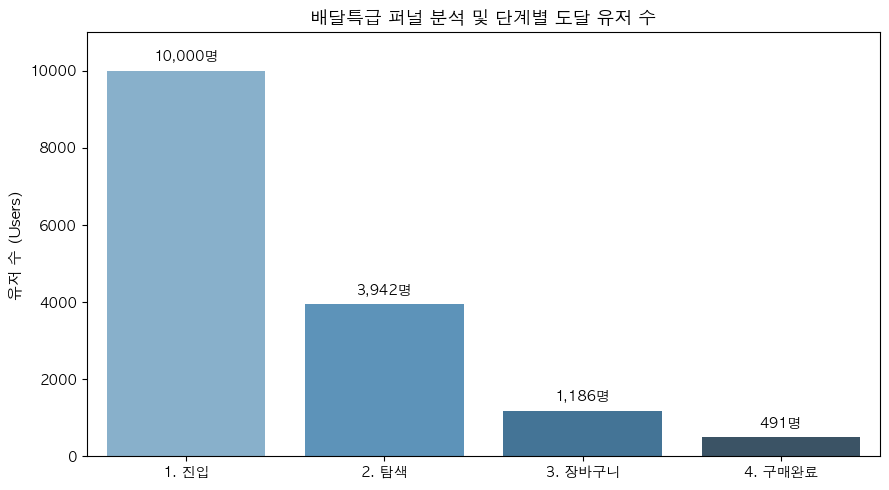

✅ 1. 전체 퍼널 차트 저장 완료 ('funnel_analysis_chart.png')


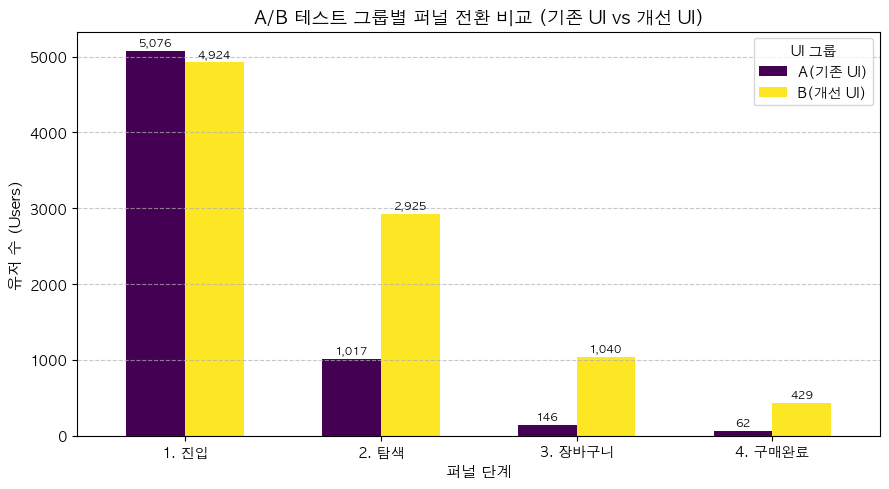

✅ 2. A/B 테스트 비교 차트 저장 완료 ('ab_test_funnel_comparison.png')


In [17]:
# 한글 폰트 및 마이너스 기호 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('delivery_app_logs.csv')
step_order = ['1_app_opened', '2_home_viewed', '3_cart_interacted', '4_purchase_completed']
step_labels = ['1. 진입', '2. 탐색', '3. 장바구니', '4. 구매완료']
funnel_counts = [df[df['step'] == s]['user_id'].nunique() for s in step_order]

print("="*60)
print(" [STEP 3] 최종 시각화 차트 생성 및 저장")
print("="*60)

# 1. 전체 퍼널 도달 유저 수 막대 차트
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=step_labels, y=funnel_counts, palette='Blues_d')
plt.title('배달특급 퍼널 분석 및 단계별 도달 유저 수', fontsize=13, fontweight='bold')
plt.ylabel('유저 수 (Users)', fontsize=11)
plt.ylim(0, 11000)

for i, v in enumerate(funnel_counts):
    ax.text(i, v + 250, f"{v:,}명", ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('funnel_analysis_chart.png', dpi=300)
plt.show()
print("✅ 1. 전체 퍼널 차트 저장 완료 ('funnel_analysis_chart.png')")

# 2. UI 그룹별(A/B 테스트) 퍼널 비교 차트
group_funnel = df.groupby(['ui_group', 'step'])['user_id'].nunique().unstack(fill_value=0)[step_order]
fig, ax = plt.subplots(figsize=(9, 5))
group_funnel.T.plot(kind='bar', ax=ax, colormap='viridis', width=0.6)
plt.title('A/B 테스트 그룹별 퍼널 전환 비교 (기존 UI vs 개선 UI)', fontsize=13, fontweight='bold')
plt.xlabel('퍼널 단계', fontsize=11)
plt.ylabel('유저 수 (Users)', fontsize=11)
plt.xticks(ticks=range(4), labels=step_labels, rotation=0)
plt.legend(title='UI 그룹', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:,}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.savefig('ab_test_funnel_comparison.png', dpi=300)
plt.show()
print("✅ 2. A/B 테스트 비교 차트 저장 완료 ('ab_test_funnel_comparison.png')")